##"Don't make changes unless it is more efficient than the previous version.
##Discuss once before changing it." - Jeevan S Hegde

#Personal Finance Prediction


##Title:
####Personal Finance Classification: Predicting Income vs Expense Using Transaction Data

In [241]:
#importing the libraries, packages and ignoring the warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [242]:
#loading the dataset
df = pd.read_csv("/content/Personal_Finance_Dataset.csv")

In [243]:
#display top part
df.head()

,Date,Transaction Description,Category,Amount,Type
0,1/2/2020,Score each.,Food & Drink,1485.69,Expense
1,1/2/2020,Quality throughout.,Utilities,1475.58,Expense
2,1/4/2020,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,1/5/2020,Information last everything thank serve.,Investment,2291.00,Income
4,1/13/2020,Future choice whatever from.,Food & Drink,1126.88,Expense


In [244]:
#information about datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


In [245]:
#show rows and columns
df.shape

(1500, 5)

In [246]:
#mathematical stats
df.describe()

,Amount
count,1500.000000
mean,1307.520913
std,982.283361
min,14.370000
25%,629.340000
50%,1156.285000
75%,1712.932500
max,4996.000000


In [247]:
#checking for null values
df.isna().sum()

,0
Date,0
Transaction Description,0
Category,0
Amount,0
Type,0


In [248]:
#clear view of dataframe
df.columns = df.columns.str.strip()

In [249]:
#conversion to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [250]:
#extracting month and date
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [251]:
#conversion to numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [252]:
df['Amount'] = np.log1p(df['Amount'])

In [253]:
#mapping income and expenses
df['Type'] = df['Type'].map({'Income': 1, 'Expense': 0})

In [254]:
#dropping null values
df = df.dropna()

In [255]:
#information about datatypes
df.head()

,Date,Transaction Description,Category,Amount,Type,Month,Day
0,2020-01-02,Score each.,Food & Drink,7.304307,0,1,2
1,2020-01-02,Quality throughout.,Utilities,7.297484,0,1,2
2,2020-01-04,Instead ahead despite measure ago.,Rent,7.078409,0,1,4
3,2020-01-05,Information last everything thank serve.,Investment,7.737180,1,1,5
4,2020-01-13,Future choice whatever from.,Food & Drink,7.028095,0,1,13


In [256]:
#conversion to integer
df['Type'] = df['Type'].astype(int)

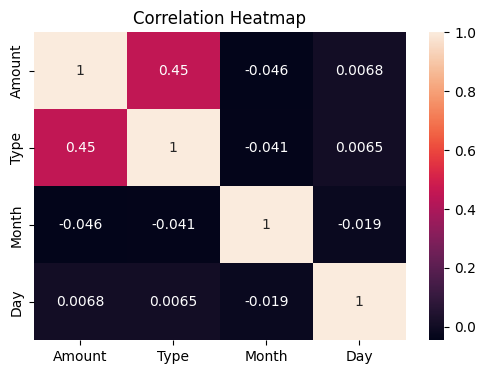

In [257]:
#HEATMAP
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

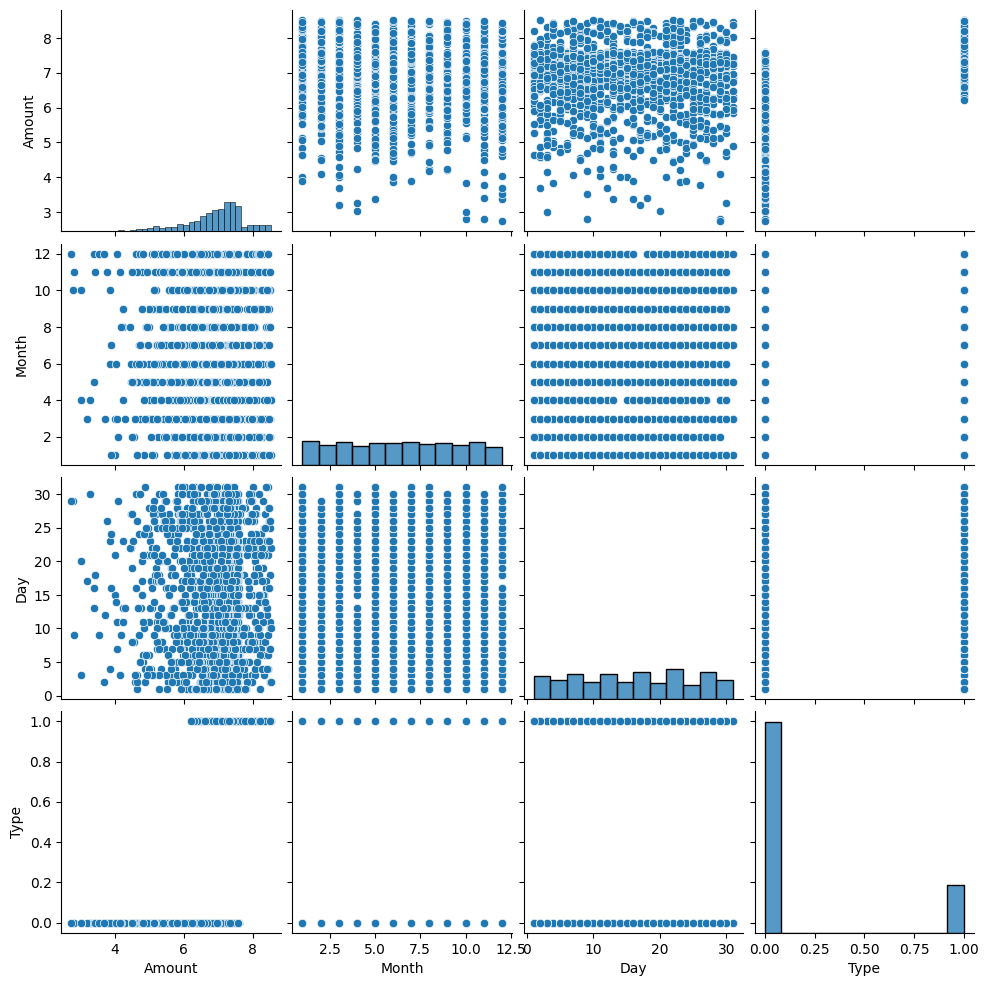

In [258]:
#PAIR PLOT
sns.pairplot(df[['Amount','Month','Day','Type']])
plt.show()

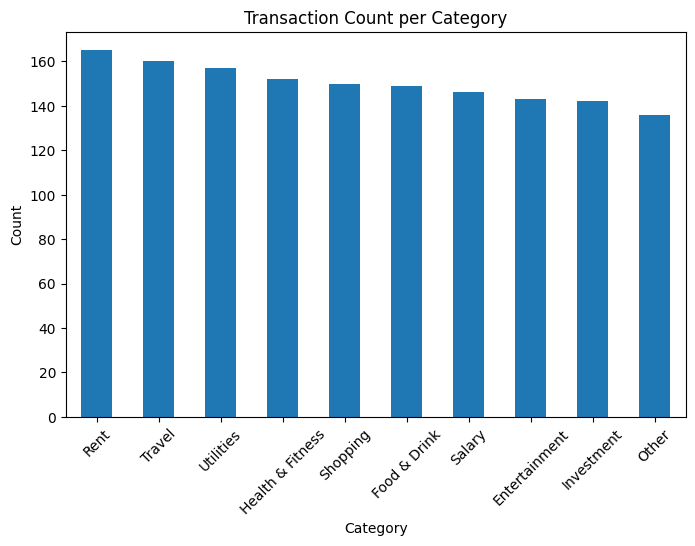

In [259]:
#BAR GRAPH (Category Count)
plt.figure(figsize=(8,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Transaction Count per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

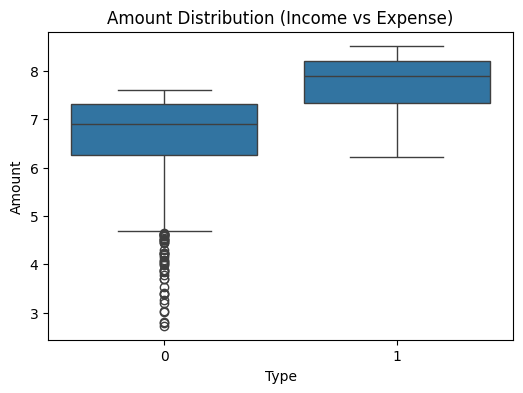

In [260]:
# BOX PLOT
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Type'], y=df['Amount'])
plt.title("Amount Distribution (Income vs Expense)")
plt.show()

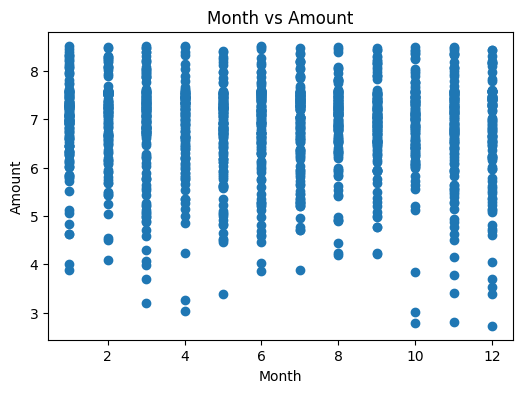

In [261]:
# SCATTER PLOT
plt.figure(figsize=(6,4))
plt.scatter(df['Month'], df['Amount'])
plt.title("Month vs Amount")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

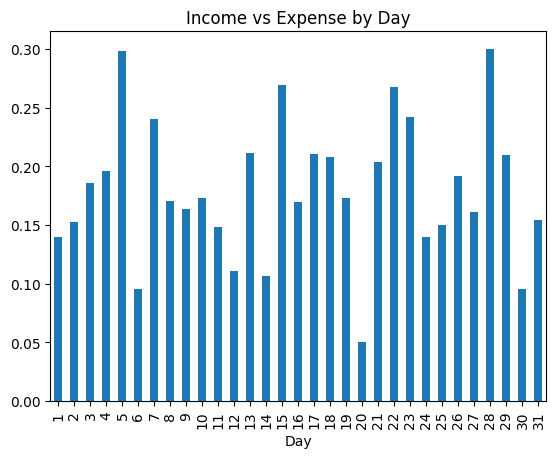

In [262]:
df.groupby('Day')['Type'].mean().plot(kind='bar')
plt.title("Income vs Expense by Day")
plt.show()

In [263]:
#train test split
from sklearn.model_selection import train_test_split

X = df[['Amount','Month','Day']]
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [264]:
#logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [265]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [266]:
#knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [267]:
#svm
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [268]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [269]:
#printing accuracy score
from sklearn.metrics import accuracy_score
print("Logistic:", accuracy_score(y_test, lr.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))
print("KNN:", accuracy_score(y_test, knn.predict(X_test)))
print("SVM:", accuracy_score(y_test, svm.predict(X_test)))
print("Naive Bayes:", accuracy_score(y_test, nb.predict(X_test)))

Logistic: 0.9233333333333333
Random Forest: 0.94
KNN: 0.8566666666666667
SVM: 0.8266666666666667
Naive Bayes: 0.9


In [270]:
#selecting the model
import pickle
pickle.dump(rf, open("model.pkl","wb"))

In [271]:
#deployment or manual input
sample = [[np.log1p(5000), 6, 2]]  # amount, month, day
prediction = rf.predict(sample)
if prediction[0] == 1:
    print("Income")
else:
    print("Expense")

Income


In [274]:
import gradio as gr
import datetime
import numpy as np

def predict_finance(amount, date_str):
    # Preprocess the input
    log_amount = np.log1p(amount)

    # Extract month and day from the date using dd-mm-yyyy
    try:
        date_obj = datetime.datetime.strptime(date_str, '%d-%m-%Y')
        month = date_obj.month
        day = date_obj.day
    except ValueError:
        return "Error: Please use dd-mm-yyyy format"

    # Predict
    features = [[log_amount, month, day]]
    pred = rf.predict(features)

    return "Income" if pred[0] == 1 else "Expense"

# Defining a custom theme for larger UI elements
large_theme = gr.themes.Default(text_size=gr.themes.sizes.text_lg, spacing_size=gr.themes.sizes.spacing_lg, radius_size=gr.themes.sizes.radius_lg)

# Create the Gradio interface with bigger elements
interface = gr.Interface(
    fn=predict_finance,
    theme=large_theme,
    inputs=[
        gr.Slider(minimum=1, maximum=10000, step=1, label="Transaction Amount", value=1000),
        gr.Textbox(label="Date (DD-MM-YYYY)", value=datetime.date.today().strftime('%d-%m-%Y'), placeholder="e.g. 25-12-2023")
    ],
    outputs=gr.Textbox(label="Predicted Category"),
    title="Personal Finance Classifier",
    description="Enter the transaction amount and date (DD-MM-YYYY) to predict if it's an Income or an Expense.",
    allow_flagging="never"
)

# Launch the interface
interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9f0badcd1634732768.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9f0badcd1634732768.gradio.live
